In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt

## Transforming data

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

In [3]:
train_data = MNIST(root="./data", train=True, transform=transform, download=True)
test_data = MNIST(root="./data",  train=False, transform=transform, download=True)

In [4]:
train_size = int(0.8 * len(train_data))
val_size = int(len(train_data) - train_size)

train_data, val_data = random_split(train_data, [train_size, val_size])

In [5]:
trainloader = DataLoader(train_data, batch_size=64, shuffle=True)
valloader = DataLoader(val_data, batch_size=64)
testloader = DataLoader(test_data, batch_size=64)

## CNN - MNIST

In [6]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layer = nn.Sequential(
            nn.Conv2d(1, 24, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(24,48, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(48, 96, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )

        self.fc_layer = nn.Sequential(
            nn.Linear(3*3*96, 234),
            nn.ReLU(),

            nn.Linear(234, 10)
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = torch.flatten(x, 1)
        x= self.fc_layer(x)
        return x

In [7]:
model = CNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

## Training the CNN

In [8]:
epochs = 10
cnn_train_loss = []
cnn_val_loss = []

for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0
    
    for images, labels in trainloader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
    epoch_train_loss = running_train_loss/len(trainloader)
    cnn_train_loss.append(epoch_train_loss)

# validating
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for images, labels in valloader:
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()
        epoch_val_loss = running_val_loss/len(valloader)
        cnn_val_loss.append(epoch_val_loss)

    print(f"epoch: {epoch+1}/{epochs}  |  train_loss: {epoch_train_loss}  |  val_loss: {epoch_val_loss}")

epoch: 1/10  |  train_loss: 0.1957841200803717  |  val_loss: 0.055368383682550905
epoch: 2/10  |  train_loss: 0.04978569457757597  |  val_loss: 0.04630234414349964
epoch: 3/10  |  train_loss: 0.034512256636284294  |  val_loss: 0.04822263436607442
epoch: 4/10  |  train_loss: 0.026949000666888122  |  val_loss: 0.028987225422826397
epoch: 5/10  |  train_loss: 0.020437503871575852  |  val_loss: 0.033064398240465843
epoch: 6/10  |  train_loss: 0.01809720854804133  |  val_loss: 0.03643810907220889
epoch: 7/10  |  train_loss: 0.015118793877249117  |  val_loss: 0.03650641849603841
epoch: 8/10  |  train_loss: 0.01330344777662443  |  val_loss: 0.029651278699223807
epoch: 9/10  |  train_loss: 0.010830996418517619  |  val_loss: 0.032765896920029666
epoch: 10/10  |  train_loss: 0.009058559900782711  |  val_loss: 0.03275651927302736


In [9]:
# Testing
y_pred = []
y_true = []

model.eval()
with torch.no_grad():
  for images, labels in testloader:
    output = model(images)
    _, predicted = torch.max(output, 1)


    y_pred.extend(predicted.numpy())
    y_true.extend(labels.numpy())

print("Accuracy: ", accuracy_score(y_pred, y_true)*100,"%")
print("confusion_matrix: \n", confusion_matrix(y_pred, y_true))

Accuracy:  99.33999999999999 %
confusion_matrix: 
 [[ 977    0    0    0    0    0    2    0    0    0]
 [   0 1134    1    0    0    0    2    4    0    0]
 [   1    0 1021    1    0    0    0    2    2    0]
 [   0    1    0 1004    0    7    2    0    1    0]
 [   0    0    0    0  978    0    2    0    0    6]
 [   0    0    0    3    0  884    0    0    0    1]
 [   1    0    1    0    1    1  948    0    0    0]
 [   1    0    9    0    0    0    0 1020    0    3]
 [   0    0    0    1    0    0    2    0  969    0]
 [   0    0    0    1    3    0    0    2    2  999]]


# RNN - MNIST


In [10]:
class RNN(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_layers=2):
        super(RNN, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 10)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)      # 1st hidden state

        out,_ = self.rnn(x, h0)
        out = self.fc(out[:,-1,:])  # passing last timestamp
        return out

In [11]:
model = RNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [12]:
epochs = 10

rnn_train_loss = []
rnn_val_loss = []

for epoch in range(epochs):
  model.train()
  running_train_loss = 0.0
  for images, labels in trainloader:
    optimizer.zero_grad()

    images = images.squeeze(1)   # (batch size, 1, 28, 28) => (batch size, 28,28)
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_train_loss += loss.item()
  epoch_train_loss = running_train_loss/len(trainloader)
  rnn_train_loss.append(epoch_train_loss)

  # VALIDATION
  model.eval()
  running_val_loss = 0.0

  for images, labels in valloader:
    optimizer.zero_grad()

    images = images.squeeze(1)   # (batch size, 1, 28, 28) => (batch size, 28,28)
    outputs = model(images)
    loss = criterion(outputs,labels)

    running_val_loss += loss.item()
  epoch_val_loss = running_val_loss/len(valloader)
  rnn_val_loss.append(epoch_val_loss)

  print(f"{epoch+1}/{epochs}  | train_loss: {epoch_train_loss}  |  val loss: {epoch_val_loss}")

1/10  | train_loss: 0.6796995029846827  |  val loss: 0.3191872740838122
2/10  | train_loss: 0.2850521824558576  |  val loss: 0.2805940587311349
3/10  | train_loss: 0.21883043865611157  |  val loss: 0.1956746785485364
4/10  | train_loss: 0.19100994234283766  |  val loss: 0.14369601751380462
5/10  | train_loss: 0.159818635409077  |  val loss: 0.15963174639507494
6/10  | train_loss: 0.15206418249880274  |  val loss: 0.12204781935570087
7/10  | train_loss: 0.1468170781483253  |  val loss: 0.16040602661272946
8/10  | train_loss: 0.1404626725713412  |  val loss: 0.2302005758033471
9/10  | train_loss: 0.128471028589954  |  val loss: 0.11998008635945301
10/10  | train_loss: 0.1279273917209357  |  val loss: 0.207393449988771


In [13]:
# Testing
y_true = []
y_pred = []

model.eval
with torch.no_grad():
  for images, labels in testloader:
    images = images.squeeze(1)
    outputs = model(images)
    _, outputs = torch.max(outputs, 1)

    y_true.extend(labels.numpy())
    y_pred.extend(outputs.numpy())

print("Accuracy:", accuracy_score(y_pred, y_true)*100, "%")
print("confusion_matrix:\n", confusion_matrix(y_pred, y_true))

Accuracy: 94.42 %
confusion_matrix:
 [[ 972    0    3    1    0   12   23    1    2    1]
 [   0 1119    2    5    3    8    5   15    6    2]
 [   0    5  998   18    0    7    5   15   10    1]
 [   0    2    5  974    0   79    1    4    3   15]
 [   2    0    5    0  955    4   21    1   11   81]
 [   1    1    0    6    0  762    6    1    4    5]
 [   1    2    3    0    1    3  890    0    4    0]
 [   2    3    5    2    5    6    0  990   11   35]
 [   2    3   11    2    1    6    7    0  916    3]
 [   0    0    0    2   17    5    0    1    7  866]]


## Performance Comparison

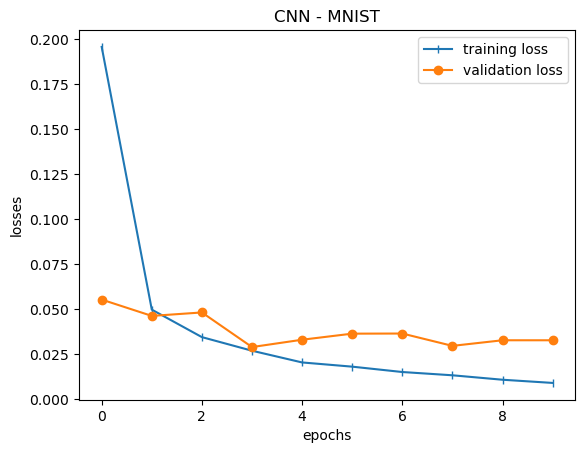

In [20]:
# CNN

df = pd.DataFrame({
    "train loss": cnn_train_loss,
    "val loss": cnn_val_loss
})

plt.plot(df["train loss"], label="training loss", marker="|")
plt.plot(df["val loss"], label="validation loss", marker="o")
plt.xlabel("epochs")
plt.ylabel("losses")
plt.title("CNN - MNIST")
plt.legend()

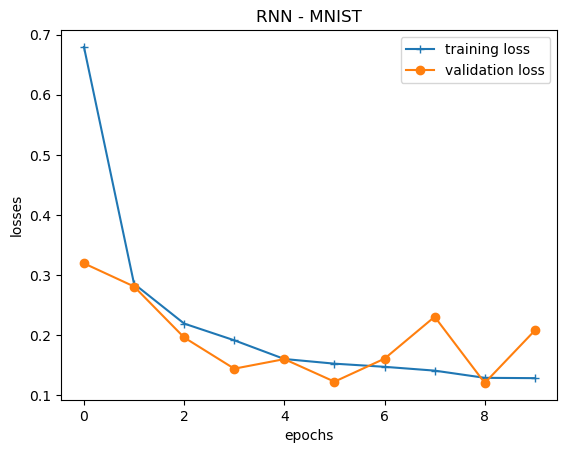

In [19]:
# RNN
df = pd.DataFrame({
    "train loss": rnn_train_loss,
    "val loss": rnn_val_loss
})

plt.plot(df["train loss"], label="training loss", marker="+")
plt.plot(df["val loss"], label="validation loss", marker="o")
plt.xlabel("epochs")
plt.ylabel("losses")
plt.title("RNN - MNIST")
plt.legend()

In [34]:
# Pass an Image

from PIL import Image

img = Image.open("./data/w9d4f.png").convert("L")       # open("Put the image path Here")
transform = transforms.Compose([
    transforms.Resize(28),              
    transforms.CenterCrop(28),
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

img = transform(img)

#pridect
model=CNN()

model.eval()
with torch.no_grad():
    output = model(img.unsqueeze(0))
    _, pred = torch.max(output, 1)

print("Pridected digit: ", pred.item())    

Pridected digit:  7
